# Rolling-Window Stationarity Check — 1-Second Brent–WTI Spread

Tests the 1-second Brent–WTI synthetic spread across separate trading-date periods with **30, 60, 120, 240, 480, 960, and 1,920-second** rolling windows. A window passes when ADF rejects a unit root and KPSS does not reject level stationarity.

In [13]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from statsmodels.tools.sm_exceptions import InterpolationWarning
from statsmodels.tsa.stattools import adfuller, kpss

warnings.filterwarnings("ignore", category=InterpolationWarning)
pd.set_option("display.max_columns", None)

In [14]:
PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "src":
    PROJECT_ROOT = PROJECT_ROOT.parent

DATA_PATH = PROJECT_ROOT / "_data" / "clean" / "brent_wti_aligned_1s_2026-06-01_2026-06-06.parquet"
OUTPUT_DIR = PROJECT_ROOT / "_output" / "stationarity_1s"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH

PosixPath('/Users/samzhang/Desktop/U CHICAGO/finm37000-grp-6-trading/_data/clean/brent_wti_aligned_1s_2026-06-01_2026-06-06.parquet')

## Load the 1-Second Spread

In [15]:
df = pd.read_parquet(DATA_PATH).sort_index()
spread = df["synth_mid"].dropna()

pd.DataFrame({
    "rows": [len(spread)],
    "start": [spread.index.min()],
    "end": [spread.index.max()],
    "mean": [spread.mean()],
    "std": [spread.std()],
    "min": [spread.min()],
    "max": [spread.max()],
}).round(4)

/var/folders/p8/1y76vmp53_xdnnmmh20lzdh80000gn/T/ipykernel_21341/971228564.py:12: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  }).round(4)


,rows,start,end,mean,std,min,max
0,410770,2026-06-01 00:00:00+00:00,2026-06-05 21:00:00+00:00,-2.4672,0.5491,-3.66,-1.0


## Candidate Rolling Windows

The candidates are **30, 60, 120, 240, 480, 960, and 1,920 seconds**. Since observations are one second apart, each window length equals its observation count. Each trading date is tested as a separate period. Samples advance by the greater of 30 seconds or one-quarter of the window.

In [16]:
CANDIDATE_WINDOWS_SECONDS = [30, 60, 120, 240, 480, 960, 1920]
ADF_ALPHA = 0.05
KPSS_ALPHA = 0.05

def test_stationarity(series):
    series = series.dropna()
    if len(series) < 20 or series.nunique() < 3:
        return None
    try:
        adf_p = adfuller(series, autolag="AIC")[1]
        kpss_p = kpss(series, regression="c", nlags="auto")[1]
    except Exception:
        return None
    return {
        "adf_pvalue": float(adf_p),
        "kpss_pvalue": float(kpss_p),
        "passes_adf": adf_p < ADF_ALPHA,
        "passes_kpss": kpss_p > KPSS_ALPHA,
        "passes_both": (adf_p < ADF_ALPHA) and (kpss_p > KPSS_ALPHA),
    }

rows = []
passing_examples = []
period_series = {str(period): values for period, values in spread.groupby(spread.index.date)}

for period, period_spread in period_series.items():
    for window_seconds in CANDIDATE_WINDOWS_SECONDS:
        if len(period_spread) < window_seconds:
            continue
        step = max(30, window_seconds // 4)
        tested = passed = adf_passed = kpss_passed = 0
        best = None

        for end in range(window_seconds, len(period_spread) + 1, step):
            sample = period_spread.iloc[end - window_seconds:end]
            result = test_stationarity(sample)
            if result is None:
                continue

            tested += 1
            adf_passed += int(result["passes_adf"])
            kpss_passed += int(result["passes_kpss"])
            passed += int(result["passes_both"])

            if result["passes_both"]:
                score = (ADF_ALPHA - result["adf_pvalue"]) + (result["kpss_pvalue"] - KPSS_ALPHA)
                candidate = {
                    "period": period,
                    "rolling_seconds": window_seconds,
                    "start": sample.index[0],
                    "end": sample.index[-1],
                    "adf_pvalue": result["adf_pvalue"],
                    "kpss_pvalue": result["kpss_pvalue"],
                    "spread_mean": sample.mean(),
                    "spread_std": sample.std(),
                    "score": score,
                }
                if best is None or candidate["score"] > best["score"]:
                    best = candidate

        if tested:
            rows.append({
                "period": period,
                "rolling_seconds": window_seconds,
                "tested_windows": tested,
                "pass_windows": passed,
                "pass_rate": passed / tested,
                "adf_pass_rate": adf_passed / tested,
                "kpss_pass_rate": kpss_passed / tested,
            })
        if best is not None:
            passing_examples.append(best)

by_period = pd.DataFrame(rows)
examples = pd.DataFrame(passing_examples)
summary = by_period.groupby("rolling_seconds").agg(
    tested_windows=("tested_windows", "sum"),
    pass_windows=("pass_windows", "sum"),
).reset_index()
summary["pass_rate"] = summary["pass_windows"] / summary["tested_windows"]
by_period.to_csv(OUTPUT_DIR / "rolling_stationarity_1s_by_period.csv", index=False)
summary.to_csv(OUTPUT_DIR / "rolling_stationarity_1s_summary.csv", index=False)
examples.to_csv(OUTPUT_DIR / "rolling_stationarity_1s_passing_examples.csv", index=False)

summary.style.format({"pass_rate": "{:.1%}"}).set_caption("Overall stationarity results by rolling window")

/Users/samzhang/anaconda3/envs/37000_project/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/samzhang/anaconda3/envs/37000_project/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/samzhang/anaconda3/envs/37000_project/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/samzhang/anaconda3/envs/37000_project/lib/python3.13/site-packages/statsmodels/regression/linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
/Users/samzhang/anaconda3/envs/37000_project/lib/python3.13/site

,rolling_seconds,tested_windows,pass_windows,pass_rate
0,30,12951,2919,22.5%
1,60,13459,2711,20.1%
2,120,13568,1924,14.2%
3,240,6792,732,10.8%
4,480,3396,194,5.7%
5,960,1694,60,3.5%
6,1920,838,16,1.9%


## Pass Rate by Rolling Window

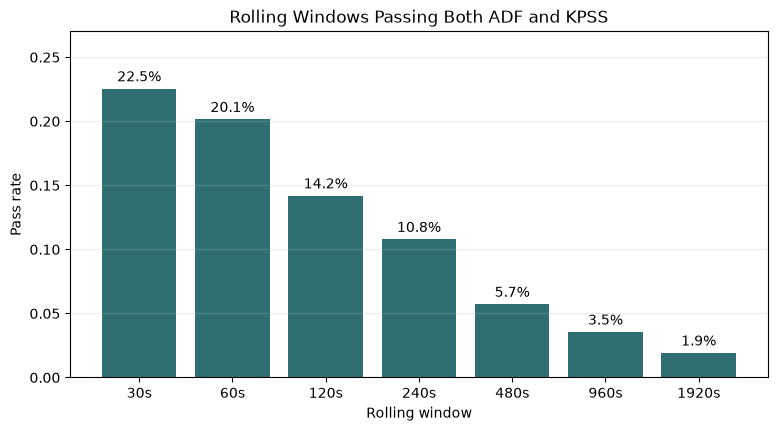

In [17]:
fig, ax = plt.subplots(figsize=(9, 4.5))
labels = summary["rolling_seconds"].map(lambda x: f"{x}s")
bars = ax.bar(labels, summary["pass_rate"], color="#2F6F73")
ax.bar_label(bars, labels=[f"{v:.1%}" for v in summary["pass_rate"]], padding=3)
ax.set_title("Rolling Windows Passing Both ADF and KPSS")
ax.set_xlabel("Rolling window")
ax.set_ylabel("Pass rate")
ax.set_ylim(0, max(0.1, summary["pass_rate"].max() * 1.2))
ax.grid(axis="y", alpha=0.25)
plt.show()

## Pass Rate by Trading-Date Period

The table and heatmap below show the percentage of tested windows that pass both ADF and KPSS for each trading date.

In [18]:
pass_rate_by_period = (
    by_period.pivot(index="period", columns="rolling_seconds", values="pass_rate")
    .reindex(columns=CANDIDATE_WINDOWS_SECONDS)
)
pass_rate_by_period.style.format("{:.1%}").set_caption("Pass rate by trading-date period and rolling window (seconds)")

rolling_seconds,30,60,120,240,480,960,1920
period,,,,,,,
2026-06-01,20.5%,19.1%,14.6%,10.6%,5.9%,5.5%,1.7%
2026-06-02,23.2%,21.0%,14.3%,11.8%,7.1%,2.9%,2.4%
2026-06-03,21.9%,19.3%,13.8%,11.1%,6.3%,3.5%,2.3%
2026-06-04,23.4%,20.2%,13.1%,9.9%,4.8%,3.2%,2.4%
2026-06-05,23.9%,21.2%,15.3%,10.4%,4.3%,2.6%,0.6%


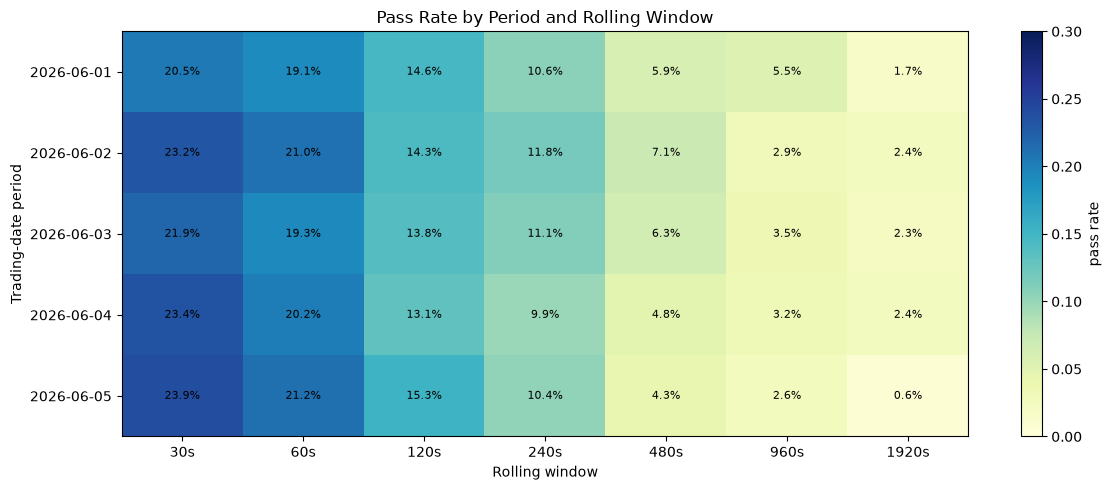

In [19]:
heat = pass_rate_by_period.fillna(0)

fig, ax = plt.subplots(figsize=(12, 5))
im = ax.imshow(heat.values, aspect="auto", cmap="YlGnBu", vmin=0, vmax=max(0.3, heat.to_numpy().max()))
ax.set_xticks(range(len(heat.columns)))
ax.set_xticklabels([f"{value}s" for value in heat.columns])
ax.set_yticks(range(len(heat.index)))
ax.set_yticklabels(heat.index)
ax.set_xlabel("Rolling window")
ax.set_ylabel("Trading-date period")
ax.set_title("Pass Rate by Period and Rolling Window")

for i in range(heat.shape[0]):
    for j in range(heat.shape[1]):
        ax.text(j, i, f"{heat.iloc[i, j]:.1%}", ha="center", va="center", fontsize=8)

fig.colorbar(im, ax=ax, label="pass rate")
plt.tight_layout()
plt.show()

## Strongest Passing Example for Each Window

In [20]:
if examples.empty:
    print("No rolling windows passed both tests.")
else:
    display(examples.drop(columns="score").sort_values("rolling_seconds").round(6))

/var/folders/p8/1y76vmp53_xdnnmmh20lzdh80000gn/T/ipykernel_21341/2553245820.py:4: UserWarning: obj.round has no effect with datetime, timedelta, or period dtypes. Use obj.dt.round(...) instead.
  display(examples.drop(columns="score").sort_values("rolling_seconds").round(6))


,period,rolling_seconds,start,end,adf_pvalue,kpss_pvalue,spread_mean,spread_std
0,2026-06-01,30,2026-06-01 06:07:00+00:00,2026-06-01 06:07:29+00:00,0.000000,0.100000,-3.509667,0.003457
14,2026-06-03,30,2026-06-03 02:25:00+00:00,2026-06-03 02:25:29+00:00,0.000000,0.100000,-2.149500,0.002403
21,2026-06-04,30,2026-06-04 20:53:00+00:00,2026-06-04 20:53:29+00:00,0.000000,0.100000,-2.220500,0.002739
7,2026-06-02,30,2026-06-02 01:33:00+00:00,2026-06-02 01:33:29+00:00,0.000000,0.100000,-2.884500,0.002013
28,2026-06-05,30,2026-06-05 05:26:30+00:00,2026-06-05 05:26:59+00:00,0.000000,0.100000,-2.324500,0.003309
22,2026-06-04,60,2026-06-04 20:21:00+00:00,2026-06-04 20:21:59+00:00,0.000000,0.100000,-2.165000,0.004783
15,2026-06-03,60,2026-06-03 02:44:00+00:00,2026-06-03 02:44:59+00:00,0.000000,0.100000,-2.139250,0.002575
8,2026-06-02,60,2026-06-02 21:10:00+00:00,2026-06-02 21:59:22+00:00,0.000000,0.100000,-2.303750,0.015060
1,2026-06-01,60,2026-06-01 05:11:30+00:00,2026-06-01 05:12:29+00:00,0.000000,0.100000,-3.419833,0.001586
29,2026-06-05,60,2026-06-05 05:23:00+00:00,2026-06-05 05:23:59+00:00,0.000000,0.100000,-2.325083,0.000645
